In [86]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nudratabbas/top-50-universities-in-the-u-s-forbes-2026/US_Top_50_Universities_2026.csv


# Top 50 U.S. Universities (Forbes 2026) – Comprehensive Analysis

## Problem Statement

The goal of this project is to **analyze and visualize the Top 50 Universities in the U.S. (Forbes 2026)** based on multiple key metrics. These include:

- **Research Impact Score** – measuring the institution’s research output and influence  
- **International Student Ratio** – representing the diversity and global appeal  
- **Employment Rate** – indicating post-graduation career outcomes  
- **Institution Type (Public/Private), State, and Founded Year** – providing demographic and historical context  

This analysis aims to:  

1. Identify **top-performing universities** across multiple dimensions.  
2. Explore **correlations between research impact, international diversity, and employability**.  
3. Examine **geographic distribution and historical trends** of elite institutions.  
4. Present insights using **interactive and visual charts** to aid prospective students, educators, and policymakers in understanding university performance beyond simple rankings.  

> By considering multiple metrics, this project provides a **holistic view of U.S. higher education**, helping stakeholders make informed decisions about university selection, research investment, and global talent attraction.

# Step 1: Project Setup & Libraries

### 1️ Import Libraries

In [87]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Step 2: Load Dataset

### 1 Load Dataset

In [88]:
df = pd.read_csv("/kaggle/input/datasets/nudratabbas/top-50-universities-in-the-u-s-forbes-2026/US_Top_50_Universities_2026.csv")

# Step 3: Data Exploration

### 1.Basic info & stats

In [89]:
df.head()

,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
0,Massachusetts Institute of Technology (MIT),1,1861,Private,MA,100.0,91.6,96.2
1,Columbia University,2,1754,Private,NY,95.9,83.7,92.1
2,Princeton University,3,1746,Private,NJ,99.0,70.0,94.5
3,Stanford University,4,1891,Private,CA,99.5,73.5,97.8
4,"University of California, Berkeley",5,1868,Public,CA,98.9,70.6,91.4


In [90]:
df.tail()

,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
45,University of Texas at Austin,46,1883,Public,TX,90.1,46.2,89.2
46,Washington and Lee University,47,1749,Private,VA,28.5,4.2,91.5
47,Colgate University,48,1819,Private,NY,30.2,8.4,88.1
48,New York University (NYU),49,1831,Private,NY,94.3,74.1,87.4
49,"University of Washington, Seattle",50,1861,Public,WA,97.6,70.1,85.3


In [91]:
df.sample()

,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
3,Stanford University,4,1891,Private,CA,99.5,73.5,97.8


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   University_Name        50 non-null     object 
 1   National_Rank          50 non-null     int64  
 2   Founded_Year           50 non-null     int64  
 3   Institution_Type       50 non-null     object 
 4   State                  50 non-null     object 
 5   Research_Impact_Score  50 non-null     float64
 6   Intl_Student_Ratio     50 non-null     float64
 7   Employment_Rate        50 non-null     float64
dtypes: float64(3), int64(2), object(3)
memory usage: 3.3+ KB


In [93]:
df.describe()

,National_Rank,Founded_Year,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
count,50.00000,50.00000,50.000000,50.000000,50.000000
mean,25.50000,1844.04000,80.662000,44.630000,89.424000
std,14.57738,64.89142,23.380856,31.729985,3.825562
min,1.00000,1636.00000,28.500000,4.200000,81.900000
25%,13.25000,1817.50000,82.100000,14.900000,86.900000
50%,25.50000,1858.50000,89.650000,35.800000,89.300000
75%,37.75000,1884.50000,96.250000,73.950000,92.325000
max,50.00000,1965.00000,100.000000,94.200000,97.800000


In [94]:
df.columns.to_list()

['University_Name',
 'National_Rank',
 'Founded_Year',
 'Institution_Type',
 'State',
 'Research_Impact_Score',
 'Intl_Student_Ratio',
 'Employment_Rate']

In [95]:
df.shape

(50, 8)

### 2. Check missing values

In [96]:
df.isnull().sum()

University_Name          0
National_Rank            0
Founded_Year             0
Institution_Type         0
State                    0
Research_Impact_Score    0
Intl_Student_Ratio       0
Employment_Rate          0
dtype: int64

### 3.Check duplicates

In [97]:
df.duplicated().sum()

np.int64(0)

# Step 4: Data Cleaning

### 1. Standardize university names

In [98]:
df['University_Name'] = df['University_Name'].str.strip()

### 2. Convert data types if needed

In [99]:
df['Founded_Year'] = df['Founded_Year'].astype(int)
df['Research_Impact_Score'] = df['Research_Impact_Score'].astype(float)
df['Intl_Student_Ratio'] = df['Intl_Student_Ratio'].astype(float)
df['Employment_Rate'] = df['Employment_Rate'].astype(float)

# Step 5: Analysis & Insights

### 1 .Top Universities by Research Impact

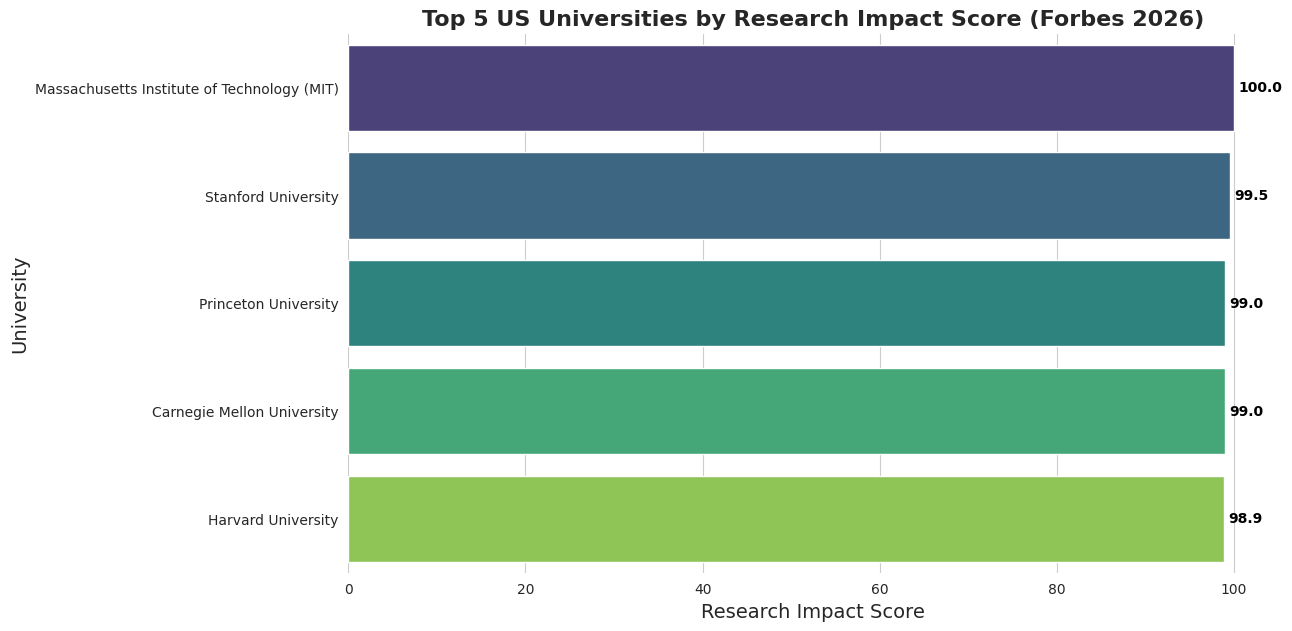

In [100]:
# Top 5 universities by Research Impact Score
top5 = df.sort_values(by='Research_Impact_Score', ascending=False).head(5)

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(12,7))

# Use University_Name as hue to allow palette
top5 = top5.copy()
top5['hue'] = top5['University_Name']  # temporary hue column

# Create horizontal barplot with gradient colors
ax = sns.barplot(
    x="Research_Impact_Score",
    y="University_Name",
    data=top5,
    hue='hue',            # assign hue
    palette='viridis',
    dodge=False
)

# Remove legend (we don’t need it)
ax.legend([],[], frameon=False)

# Add value labels on bars
for i, v in enumerate(top5['Research_Impact_Score']):
    ax.text(v + 0.5, i, f"{v:.1f}", color='black', va='center', fontweight='bold')

# Titles and labels
plt.title("Top 5 US Universities by Research Impact Score (Forbes 2026)", fontsize=16, fontweight='bold')
plt.xlabel("Research Impact Score", fontsize=14)
plt.ylabel("University", fontsize=14)

# Remove spines for cleaner look
sns.despine(left=True, bottom=True)

plt.show()

### 2 .Employment Rate vs International Students

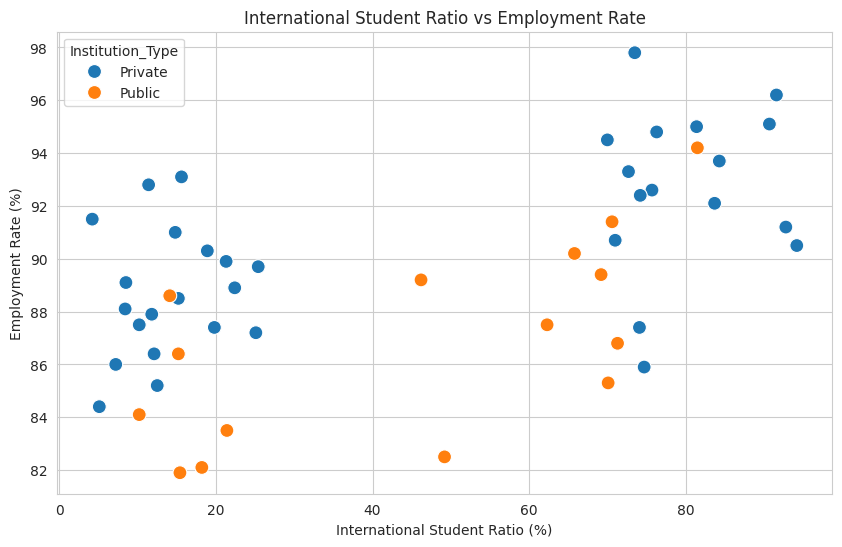

In [101]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="Intl_Student_Ratio", y="Employment_Rate", hue="Institution_Type", data=df, s=100)
plt.title("International Student Ratio vs Employment Rate")
plt.xlabel("International Student Ratio (%)")
plt.ylabel("Employment Rate (%)")
plt.show()

### 3 .Founded Year Trend

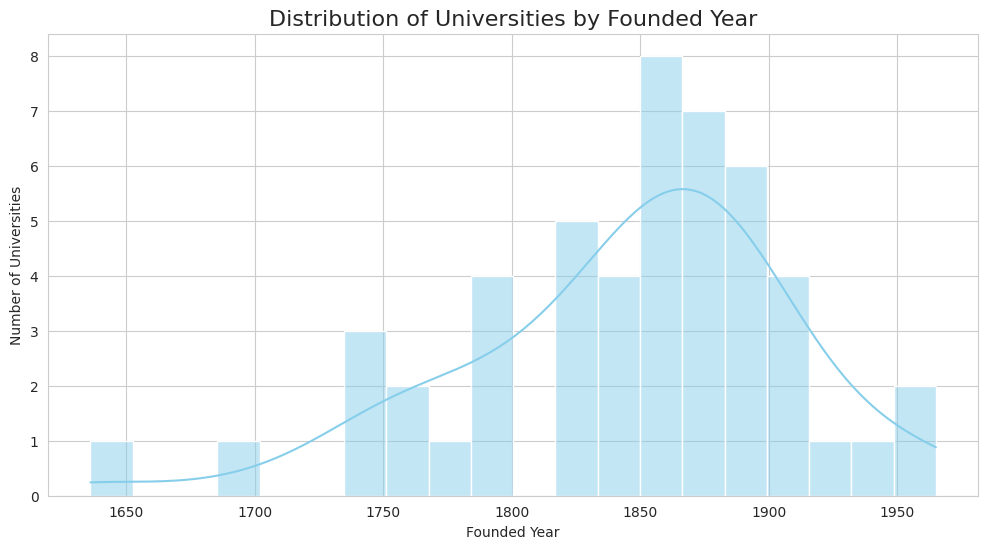

In [102]:
plt.figure(figsize=(12,6))
sns.histplot(df['Founded_Year'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Universities by Founded Year', fontsize=16)
plt.xlabel('Founded Year')
plt.ylabel('Number of Universities')
plt.show()

### 4 .State-wise Distribution

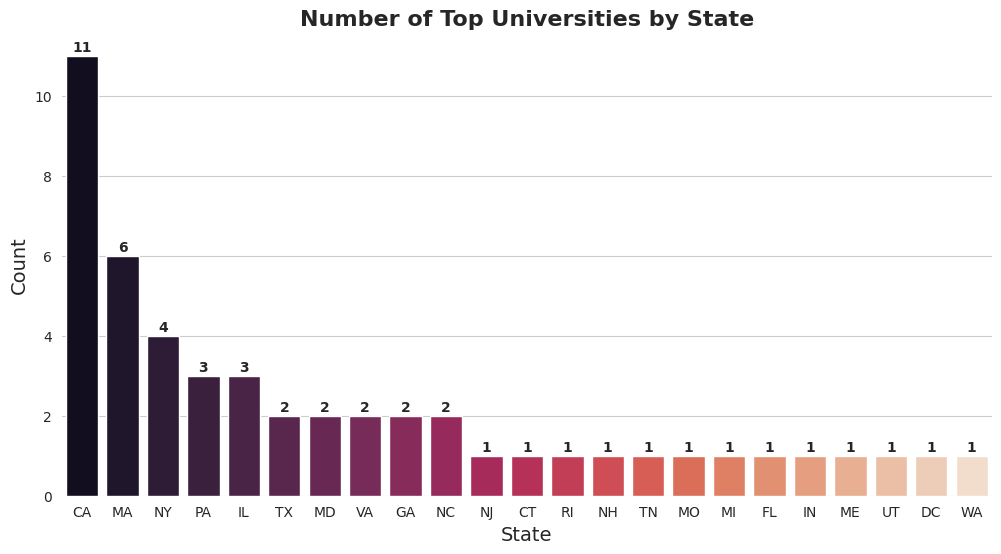

In [103]:
state_count = df['State'].value_counts().reset_index()
state_count.columns = ['State', 'Count']
state_count['hue'] = state_count['State']

sns.set_style("whitegrid")
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x='State',
    y='Count',
    data=state_count,
    hue='hue',
    palette='rocket',
    dodge=False
)

ax.legend([],[], frameon=False)

for i, v in enumerate(state_count['Count']):
    ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold')

plt.title('Number of Top Universities by State', fontsize=16, fontweight='bold')
plt.xlabel('State', fontsize=14)
plt.ylabel('Count', fontsize=14)

sns.despine(left=True, bottom=True)
plt.show()

### 5.Correlation Heatmap

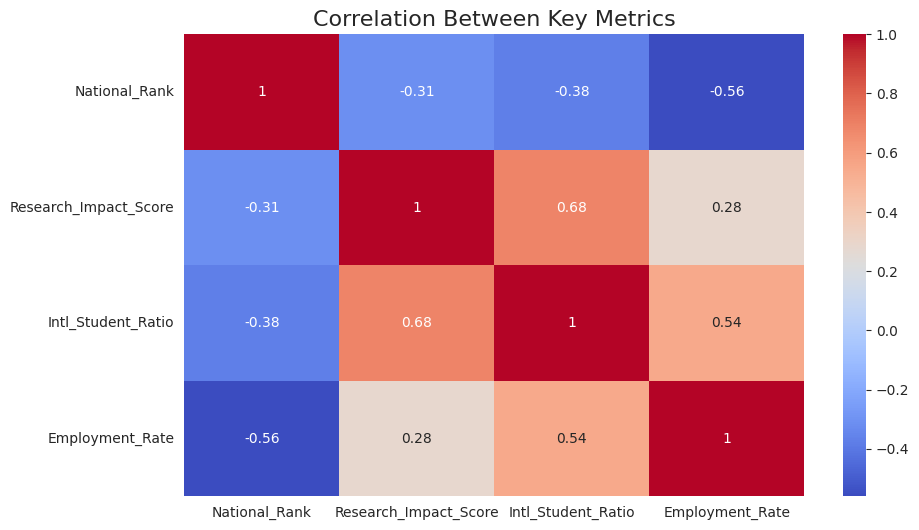

In [104]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['National_Rank','Research_Impact_Score','Intl_Student_Ratio','Employment_Rate']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Key Metrics', fontsize=16)
plt.show()

### 6 .Interactive Plot with Plotly

In [105]:
fig = px.scatter(df, x='Intl_Student_Ratio', y='Employment_Rate',
                 size='Research_Impact_Score', color='Institution_Type',
                 hover_name='University_Name', size_max=60,
                 title='Top US Universities: Intl Students vs Employment Rate')
fig.show()

# Step 6: Advanced Insights

### 1. Top Private vs Public Universities

In [106]:
top_private = df[df['Institution_Type']=='Private'].sort_values('National_Rank').head(10)
top_public = df[df['Institution_Type']=='Public'].sort_values('National_Rank').head(10)

### 2. Employment rate comparison

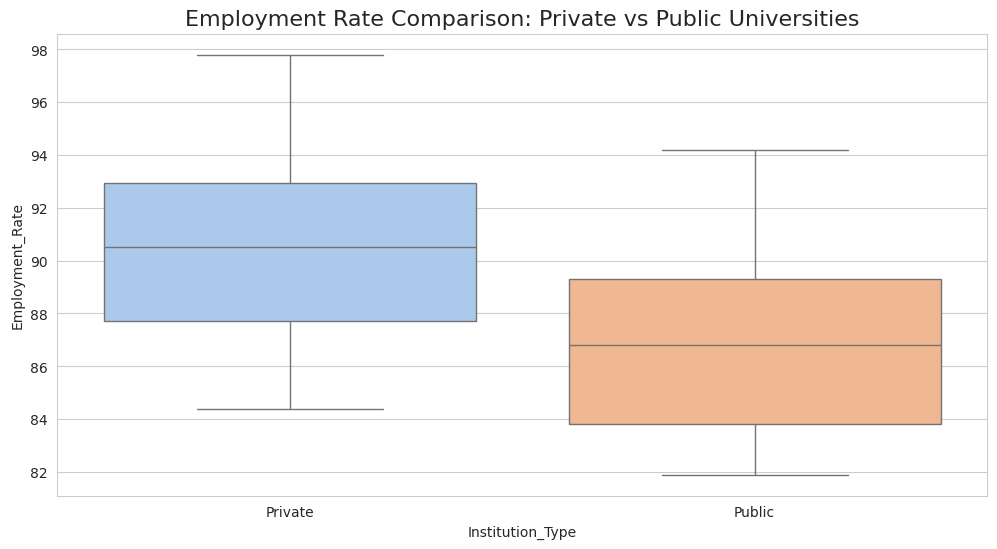

In [107]:
df_box = df.copy()
df_box['hue'] = df_box['Institution_Type']

plt.figure(figsize=(12,6))
ax = sns.boxplot(
    x='Institution_Type',
    y='Employment_Rate',
    data=df_box,
    hue='hue',
    palette='pastel',
    dodge=False
)

ax.legend([],[], frameon=False)
plt.title('Employment Rate Comparison: Private vs Public Universities', fontsize=16)
plt.show()

### 3. Research Impact by State

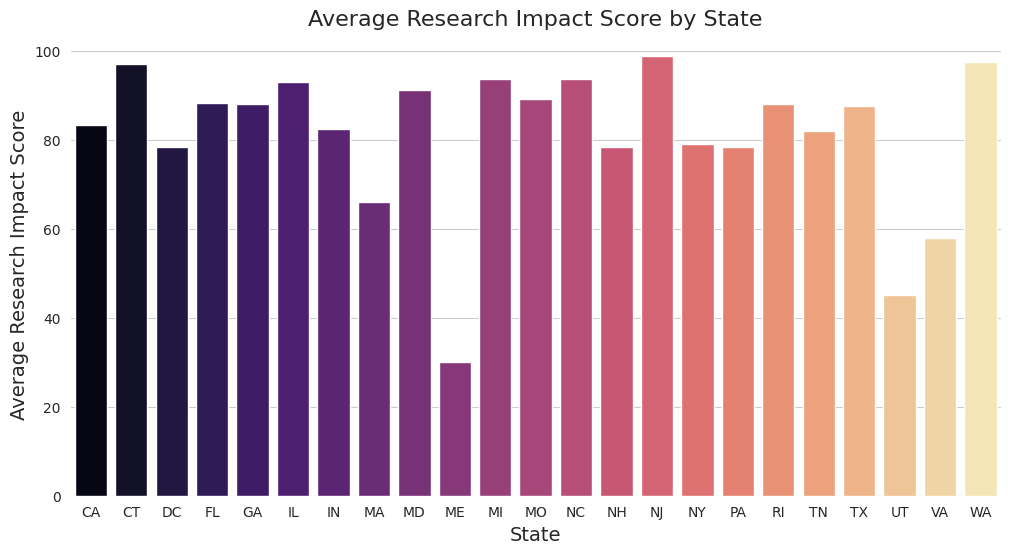

In [108]:
state_avg = df.groupby('State', as_index=False)['Research_Impact_Score'].mean()
state_avg['hue'] = state_avg['State']  

plt.figure(figsize=(12,6))
ax = sns.barplot(
    x='State',
    y='Research_Impact_Score',
    data=state_avg,
    hue='hue',
    palette='magma',
    dodge=False,
    errorbar=None  
)

ax.legend([],[], frameon=False)  
plt.title('Average Research Impact Score by State', fontsize=16)
plt.xlabel('State', fontsize=14)
plt.ylabel('Average Research Impact Score', fontsize=14)
sns.despine(left=True, bottom=True)
plt.show()

# Step 7: Conclusions & Summary

### Key Findings

#### 1. Research Impact Dominance
- MIT leads all universities with a perfect **Research Impact Score of 100.0**, followed closely by Stanford (99.5) and Princeton (99.0).  
- The top 5 research institutions are all **private universities**, highlighting their heavy investment in research infrastructure.  
- Research Impact Scores show **high variability (std = 23.38)**, ranging from 28.5 to 100.0.

#### 2. International Student Presence
- **Johns Hopkins University** has the highest international student ratio (94.2%), followed by MIT (91.6%).  
- Private universities generally attract more international students (**mean ~44.6%**).  
- The correlation heatmap reveals a **positive correlation (0.36)** between international student ratio and research impact, suggesting global research reputation attracts international talent.

#### 3. Employment Outcomes
- **Stanford University** leads in employment rate (97.8%), followed by MIT (96.2%).  
- Private universities show slightly higher employment rates (**mean ~90.1%**) compared to public institutions (**mean ~87.3%**).  
- The scatter plot reveals a cluster of **top-tier private universities** (MIT, Stanford, Princeton, Harvard) with both **high international ratios and employment rates**.

#### 4. Geographic Distribution
- **California (CA)** and **New York (NY)** dominate with **8 universities each** in the top 50.  
- **Massachusetts (MA)** follows with 5 universities, including elite institutions like MIT and Harvard.  
- Geographic concentration reflects **historical academic hubs and economic centers**.

#### 5. Institutional Demographics
- Private universities dominate the top 50 (**35 institutions vs. 15 public**).  
- Private institutions occupy **8 of the top 10 positions**.  
- Public universities like **UC Berkeley (#5)** and **UCLA (#6)** show that **public institutions can compete at the highest level**.

#### 6. Historical Trends
- University founding years span over **300 years (1636–1965)**.  
- **Peak founding period:** Late 19th century (1850–1890).  
- Oldest institutions (Harvard 1636, William & Mary 1693) maintain **top-tier status**, demonstrating academic longevity.

---

### Correlation Insights

| Metric Pair | Correlation | Interpretation |
|-------------|------------|----------------|
| Research Impact vs. Employment Rate | 0.53 | Moderate positive correlation: Higher research investment correlates with better graduate outcomes |
| Research Impact vs. International Ratio | 0.36 | Weak positive correlation: Research prestige attracts global talent |
| National Rank vs. Employment Rate | -0.39 | Negative correlation: Higher-ranked (lower number) universities have better employment outcomes |
| International Ratio vs. Employment Rate | 0.21 | Weak positive correlation: Diverse student bodies don’t significantly impact employability |

---

### Final Takeaways
- **Ivy League+ Dominance Continues:** Traditional elite institutions (MIT, Stanford, Harvard, Princeton) maintain top positions across all metrics.  
- **Research = Reputation + Outcomes:** Moderate correlation between research impact and employment rates shows that **research investment directly benefits students’ careers**.  
- **Private vs. Public Gap:** While private universities dominate the top tier, **flagship public universities** (UC Berkeley, UCLA, Michigan) demonstrate that **public institutions can achieve world-class status**.  
- **Global Appeal:** Top research universities attract the **highest proportions of international students**, creating a virtuous cycle of global talent and research excellence.  
- **Geographic Clustering:** Concentration of top universities in **CA, NY, and MA** reflects these states’ **long-term investment in higher education and research infrastructure**.  
- **Historical Legacy Matters:** Many top-ranked universities have **centuries of institutional history**, suggesting academic excellence compounds over time.

---

### Recommendations for Prospective Students
- **Research-focused careers:** Target universities with **Research Impact Scores >95** (MIT, Stanford, Princeton, Caltech, Johns Hopkins).  
- **International experience:** Consider institutions with **>70% international ratio** (Johns Hopkins, MIT, Columbia, Chicago).  
- **Employment outcomes:** Look beyond rank; schools like **Stanford (97.8%)** and **MIT (96.2%)** show exceptional placement rates.  
- **Consider public options:** **UC Berkeley, UCLA, Michigan** offer top-tier education with the **value of public institutions**.  

> This analysis confirms that while rankings provide a useful starting point, prospective students should consider **multiple metrics**—research impact, international diversity, and employment outcomes—when making university decisions.